In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import GridSearchCV



In [2]:
df = pd.read_csv('alzheimers_disease_data.csv')
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1, errors='ignore')

In [3]:
selected_features = [
    'FunctionalAssessment',
    'ADL',
    'MemoryComplaints',
    'BehavioralProblems',
    'MMSE',
    'DietQuality',
    'SleepQuality',
    'PhysicalActivity',
    'BMI',
    'AlcoholConsumption',
    'Smoking',
    'CholesterolTotal',
    'CholesterolTriglycerides',
    'CholesterolHDL',
    'CholesterolLDL',
    'DiastolicBP',
    'Depression',
    'SystolicBP',
    'Age',
    'Ethnicity'
]

In [4]:
X = df[selected_features]
y = df['Diagnosis']

In [6]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(X)), int(0.8*len(y))])

C:\Users\aveli\anaconda3\envs\cop501CW\lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [7]:
def scale_dataset(dataframe, oversample = False):
    X = dataframe.iloc[:, :-1].values
    y = dataframe.iloc[:, -1].values
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)
       
        
    
    data = np.hstack((X, np.reshape(y, (-1, 1))))
    return data , X, y



In [8]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

Gradient Boosting

In [9]:
from sklearn.ensemble import GradientBoostingClassifier


In [10]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [11]:
y_pred = gb_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.95      0.95       287
           1       0.89      0.89      0.89       143

    accuracy                           0.93       430
   macro avg       0.92      0.92      0.92       430
weighted avg       0.93      0.93      0.93       430

[[272  15]
 [ 16 127]]


In [12]:
y_val_probs = gb_model.predict_proba(X_valid)[:, 1]
y_test_probs = gb_model.predict_proba(X_test)[:, 1]

In [13]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [14]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

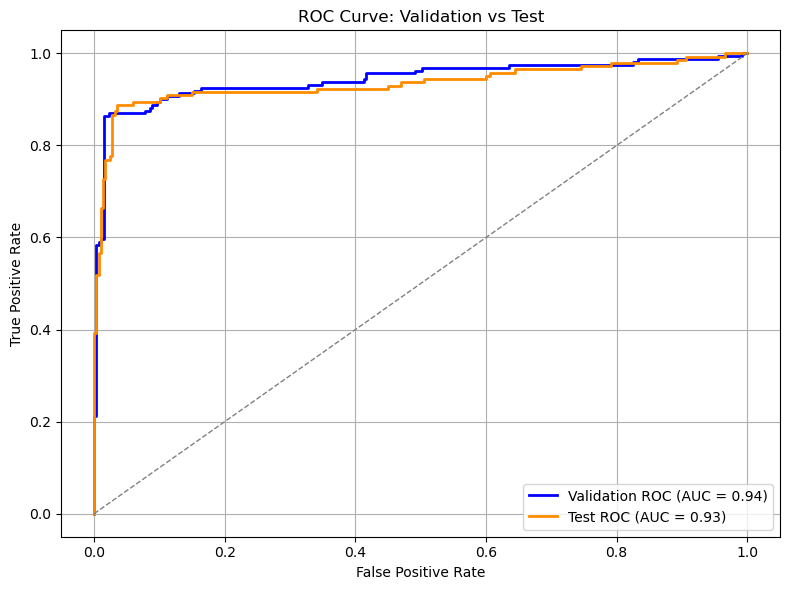

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Hyperparamenter tuning 

In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
}

In [17]:
gb_model = GradientBoostingClassifier()
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [18]:
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.95      0.95       287
           1       0.91      0.87      0.89       143

    accuracy                           0.93       430
   macro avg       0.92      0.91      0.92       430
weighted avg       0.93      0.93      0.93       430

[[274  13]
 [ 18 125]]
